# Fundamental frequency detection

This notebook demonstrates fundamental frequency ($f_0$) detection using the SMS-tools library. It is organized in three sections:

1. **Load** the sound file and set the analysis parameters.
2. **Single-frame analysis**: extract one DFT frame, detect peaks, and run the TWM algorithm to find the best $f_0$ candidate.
3. **Whole-sound analysis**: track $f_0$ frame by frame with `f0Detection`, plot the contour on the spectrogram, and synthesize it with `sinewaveSynth`.


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.signal import get_window
from smstools.models import dftModel as DFT
from smstools.models import harmonicModel as HM
from smstools.models import stft
from smstools.models import utilFunctions as UF
import plot_helpers as PH

PH.setup_plot_style()

## 1. Load the sound and set the analysis parameters


In [32]:
input_file = '../sounds/cello-phrase.wav'
window = 'blackman'
M = 1201
N = 2048
H = 128
t = -100
minf0 = 50
maxf0 = 500
f0et = 1
fs, x = UF.wavread(input_file)
w = get_window(window, M)
print(f'Sampling rate: {fs} Hz')
print(f'Duration: {len(x) / fs:.2f} s')
ipd.display(ipd.Audio(data=x, rate=fs))


Sampling rate: 44100 Hz
Duration: 8.48 s


## 2. Analysis of a single frame

Here we extract one analysis frame at $t = 1.75\,\text{s}$, compute its DFT with `dftAnal`, detect and interpolate spectral peaks with `peakDetection` + `peakInterp`, and then run the TWM algorithm over a range of candidate frequencies. The first plot shows the magnitude spectrum together with the detected peaks and the harmonic series of the best $f_0$ candidate. The second plot shows the TWM error curve for all candidates.


Frame time: 2.00 s
Number of detected/interpolated peaks: 148
Best candidate from TWM (Hz): 444.0


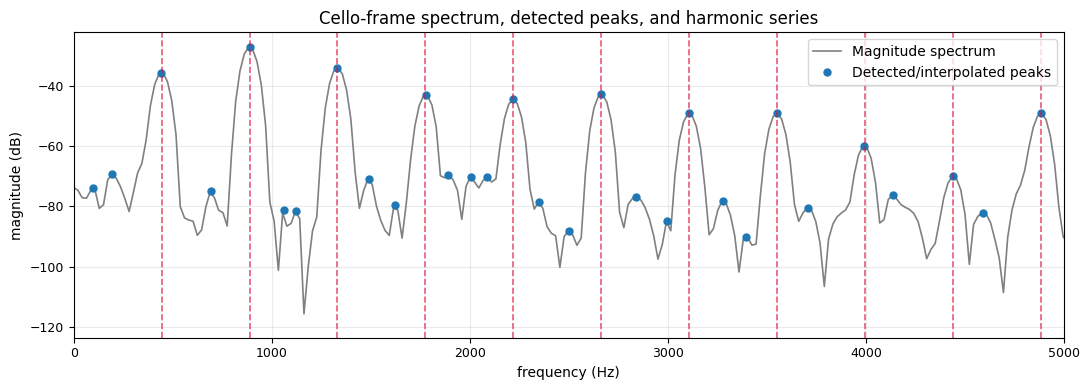

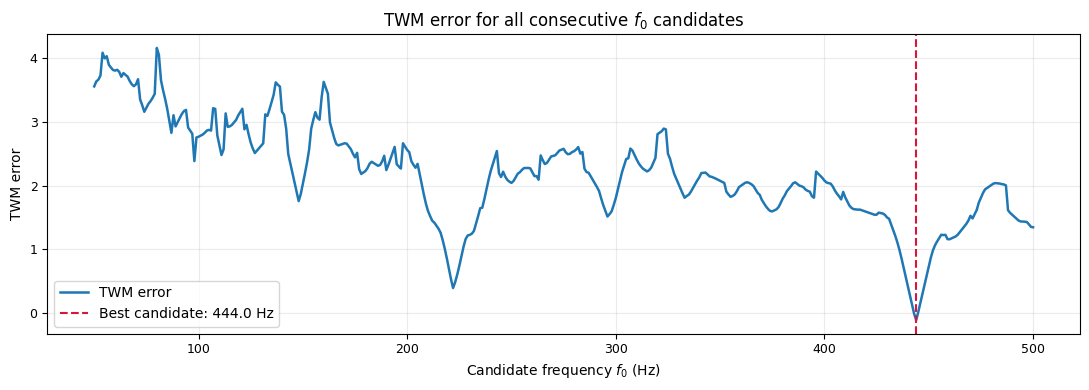

In [33]:
frame_time = 2
pin = int(frame_time * fs)
hM1 = (M + 1) // 2
hM2 = M // 2
if pin - hM1 < 0 or pin + hM2 > len(x):
    raise ValueError('Selected frame is outside the signal range')
x_frame = x[pin - hM1:pin + hM2]
mX_frame, pX_frame = DFT.dftAnal(x_frame, w, N)
ploc = UF.peakDetection(mX_frame, t)
iploc, ipmag, ipphase = UF.peakInterp(mX_frame, pX_frame, ploc)
pfreq = fs * iploc / float(N)
pmag = ipmag
f0c = np.arange(minf0, maxf0 + 1, 1.0)
def twm_error_curve(pfreq, pmag, f0c):
    p = 0.5
    q = 1.4
    r = 0.5
    rho = 0.33
    maxnpeaks = 10
    Amax = np.max(pmag)
    MaxNPM = min(maxnpeaks, pfreq.size)
    MaxNMP = min(maxnpeaks, pfreq.size)
    ErrorPM = np.zeros(f0c.size)
    for i in range(MaxNPM):
        harmonic = f0c * (i + 1)
        difmatrixPM = np.abs(harmonic[:, None] - pfreq[None, :])
        FreqDistance = np.min(difmatrixPM, axis=1)
        peakloc = np.argmin(difmatrixPM, axis=1)
        Ponddif = FreqDistance * (harmonic ** (-p))
        PeakMag = pmag[peakloc]
        MagFactor = 10 ** ((PeakMag - Amax) / 20)
        ErrorPM += Ponddif + MagFactor * (q * Ponddif - r)
    ErrorMP = np.zeros(f0c.size)
    for i, candidate in enumerate(f0c):
        nharm = np.round(pfreq[:MaxNMP] / candidate)
        nharm = np.where(nharm >= 1, nharm, 1)
        FreqDistance = np.abs(pfreq[:MaxNMP] - nharm * candidate)
        Ponddif = FreqDistance * (pfreq[:MaxNMP] ** (-p))
        PeakMag = pmag[:MaxNMP]
        MagFactor = 10 ** ((PeakMag - Amax) / 20)
        ErrorMP[i] = np.sum(MagFactor * (Ponddif + MagFactor * (q * Ponddif - r)))
    Error = (ErrorPM / MaxNPM) + (rho * ErrorMP / MaxNMP)
    best_idx = np.argmin(Error)
    return Error, best_idx
error_curve, best_idx = twm_error_curve(pfreq, pmag, f0c)
best_f0 = f0c[best_idx]
print(f'Frame time: {frame_time:.2f} s')
print(f'Number of detected/interpolated peaks: {pfreq.size}')
print('Best candidate from TWM (Hz):', np.round(best_f0, 2))
frame_bin_freqs = np.arange(mX_frame.size) * fs / float(N)
max_harm = int(np.floor(pfreq.max() / best_f0))
harmonics = best_f0 * np.arange(1, max_harm + 1)
fig, ax = plt.subplots(figsize=(11, 4))
PH.plot_spectrum_series(
    ax,
    frame_bin_freqs,
    [
        {'y': mX_frame, 'color': 'gray', 'linewidth': 1.2, 'label': 'Magnitude spectrum'},
        {'x': pfreq, 'y': pmag, 'color': 'tab:blue', 'marker': 'o', 'linewidth': 0, 'markersize': 5, 'label': 'Detected/interpolated peaks'},
    ],
    title='Cello-frame spectrum, detected peaks, and harmonic series',
)
for i, harmonic in enumerate(harmonics):
    label = 'Harmonic series of best $f_0$' if i == 0 else None
    ax.axvline(harmonic, color='crimson', linestyle='--', linewidth=1.2, alpha=0.7, label=label)
ax.set_xlim(0, min(5000, frame_bin_freqs[-1]))
ax.set_ylim(np.min(mX_frame) - 5, np.max(mX_frame) + 5)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(11, 4))
PH.plot_spectrum_series(
    ax2,
    f0c,
    [
        {'y': error_curve, 'color': 'tab:blue', 'linewidth': 1.8, 'label': 'TWM error'},
    ],
    title='TWM error for all consecutive $f_0$ candidates',
    xlabel='Candidate frequency $f_0$ (Hz)',
    ylabel='TWM error',
)
ax2.axvline(best_f0, color='crimson', linestyle='--', linewidth=1.5, label=f'Best candidate: {best_f0:.1f} Hz')
ax2.legend()
plt.tight_layout()
plt.show()

Total peaks detected: 148
Candidates in [50, 500] Hz: 3
Candidate frequencies (Hz): [ 97.89 195.28 443.51]


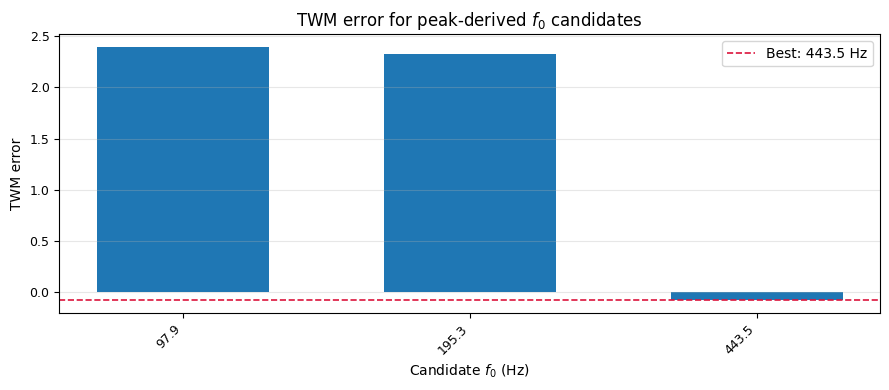

In [34]:
f0t = 0  # no previous frame f0 (first frame)
candidate_idx = np.flatnonzero((pfreq > minf0) & (pfreq < maxf0))
f0_candidates = pfreq[candidate_idx]
f0_candidate_mag = pmag[candidate_idx]
if f0t > 0:
    shortlist = np.flatnonzero(np.abs(f0_candidates - f0t) < f0t / 2.0)
    maxc = np.argmax(f0_candidate_mag)
    maxcfd = f0_candidates[maxc] % f0t
    if maxcfd > f0t / 2:
        maxcfd = f0t - maxcfd
    if (maxc not in shortlist) and (maxcfd > (f0t / 4)):
        shortlist = np.append(maxc, shortlist)
    f0_candidates = f0_candidates[shortlist]
print(f'Total peaks detected: {pfreq.size}')
print(f'Candidates in [{minf0}, {maxf0}] Hz: {f0_candidates.size}')
print('Candidate frequencies (Hz):', np.round(f0_candidates, 2))
candidate_errors = np.array([twm_error_curve(pfreq, pmag, np.array([c]))[0][0] for c in f0_candidates])
best_candidate = f0_candidates[np.argmin(candidate_errors)]
plt.figure(figsize=(9, 4))
plt.bar(np.arange(f0_candidates.size), candidate_errors, color='tab:blue', width=0.6)
plt.xticks(np.arange(f0_candidates.size), [f'{f:.1f}' for f in f0_candidates], rotation=45, ha='right')
plt.axhline(candidate_errors.min(), color='crimson', linestyle='--', linewidth=1.2, label=f'Best: {best_candidate:.1f} Hz')
plt.xlabel('Candidate $f_0$ (Hz)')
plt.ylabel('TWM error')
plt.title('TWM error for peak-derived $f_0$ candidates')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Analysis of the whole sound

`f0Detection` applies the TWM detector to every frame and returns a per-frame $f_0$ array. Below we plot the detected contour on top of the spectrogram and then synthesize it with `sinewaveSynth`.


Frames analyzed: 2923
Voiced frames: 2745


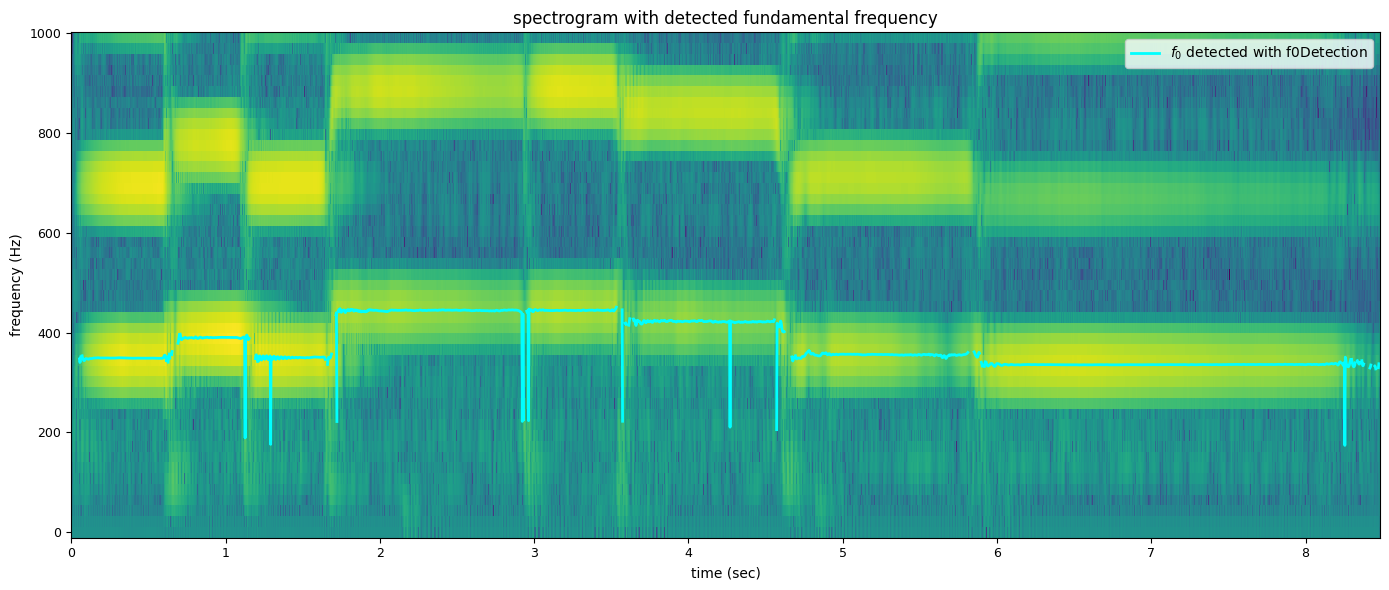

In [35]:
f0 = HM.f0Detection(x, fs, w, N, H, t, minf0, maxf0, f0et)
frame_times = H * np.arange(f0.size) / float(fs)
print(f'Frames analyzed: {f0.size}')
print(f'Voiced frames: {np.count_nonzero(f0)}')
maxplotfreq = 1000.0
mX, _ = stft.stftAnal(x, w, N, H)
fig, ax = plt.subplots(figsize=(14, 6))
PH.plot_spectrogram_with_tracks(
    ax,
    mX,
    f0[:, np.newaxis],
    fs,
    N,
    H,
    max_plot_freq=maxplotfreq,
    title='spectrogram with detected fundamental frequency',
    track_color='cyan',
    track_linewidth=2.0,
    track_alpha=1.0,
    cmap=None,
    )
ax.legend(['$f_0$ detected with f0Detection'], loc='upper right')
plt.tight_layout()
plt.show()

In [36]:
y_f0 = UF.sinewaveSynth(f0, 0.8, H, fs)
print('Synthesized $f_0$ trajectory:')
ipd.display(ipd.Audio(data=y_f0, rate=fs))


Synthesized $f_0$ trajectory:
